# Problem: Adversarial Attacks

If you encounter the following error while running the notebook:

```text
Running cells with '.venv (Python 3.12.12)' requires the ipykernel package.
Install 'ipykernel' into the Python environment. 
```

Please run the following command in your terminal:
```bash
pip install -i https://mirror-pypi.runflare.com/simple ipykernel
```

## **<span style="color:orange">Importing Libraries, Declaring Constants, Setting Seed & DEVICE </span>**

Installation

In [59]:
# %pip install -i https://mirror-pypi.runflare.com/simple torch torchvision matplotlib tqdm numpy

To load the downloaded weights, you'll need the `pytorch_cifar_models` package. Please ensure that you place the downloaded `pytorch_cifar_models` folder (from elearn) in the same directory as your code.

Alternatively, you can clone the repository directly by running the following command in your terminal:
```bash
!git clone https://github.com/chenyaofo/pytorch-cifar-models.git


In [60]:
import sys
sys.path.append("pytorch-cifar-models")

import pytorch_cifar_models as pcm

Library

In [61]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

Set DEVICE

In [62]:
DEVICE = "cpu"
# if torch.backends.mps.is_available():
#     DEVICE = "mps"
# elif torch.cuda.is_available():
#     DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: cpu


Constants

In [63]:
BATCH_SIZE = 4

In [64]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [65]:
CIFAR10_DIR = "./cifar10_correct_samples"
RESENET20_WEIGHTS = "./cifar10_resnet20-4118986f.pt"

## **<span style="color:orange">Load Model & Data</span>**

Load model

In [66]:
model = pcm.cifar10_resnet20(pretrained=False)

In [67]:
state_dict = torch.load(RESENET20_WEIGHTS, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
model.to(DEVICE)

C:\Users\NoteBook\AppData\Local\Temp\ipykernel_4280\1993339582.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(RESENET20_WEIGHTS, map_location=DE

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Load image

In [68]:
class CIFARCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.files = [
            f for f in os.listdir(root_dir)
            if f.endswith(".png")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.root_dir, filename)

        # load image
        image = Image.open(path).convert("RGB")

        # parse label from filename: "..._true3.png"
        label_str = filename.split("_true")[1].split(".png")[0]
        label = int(label_str)

        if self.transform:
            image = self.transform(image)

        return image, label

In [69]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.flatten().tolist(),
                        std=std.flatten().tolist())
])

dataset = CIFARCustomDataset(
    root_dir=CIFAR10_DIR,
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [70]:
print(f"Number of images: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Number of images: 25
Number of batches: 7


Check Model and Dataset Load

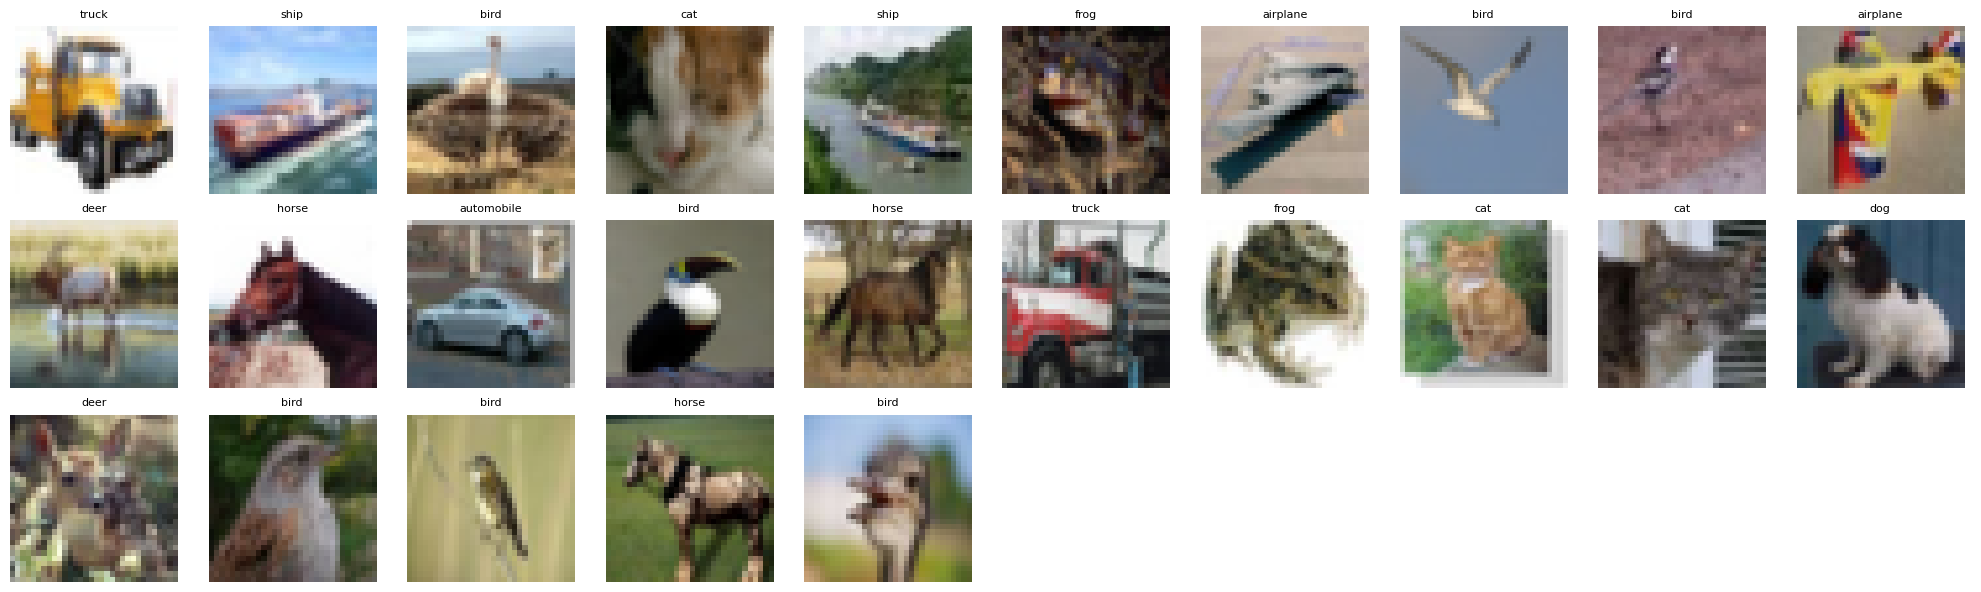

In [71]:
num_images = len(dataset)
cols = 10
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    img, true_lbl = dataset[i]
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{CIFAR10_CLASSES[true_lbl]}", fontsize=8)
    axes[i].axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [72]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [73]:
accuracy_clean_data = evaluate(model, dataloader)
print(f"Accuracy of the model on the {len(dataset)} clean images: {accuracy_clean_data:.4f}")

100%|██████████| 7/7 [00:00<00:00, 74.34it/s]

Accuracy of the model on the 25 clean images: 1.0000


## **<span style="color:orange">Attacks</span>**

## FGSM Attack


#### FGSM Attack Implementation

In [74]:
def fgsm_attack(model, images, labels, epsilon, mean, std):
    """
    Fast Gradient Sign Method (FGSM) Attack
    
    Args:
        model: Trained model
        images: Batch of input images (normalized)
        labels: True labels
        epsilon: Perturbation magnitude (in standardized space: mean=0, std=1)
        mean: Mean tensor used for normalization
        std: Standard deviation tensor used for normalization
    
    Returns:
        perturbed_images: Adversarial images
        noise: The added perturbation
    """
    # Enable gradient tracking on input images
    images.requires_grad = True
    
    # Forward pass
    outputs = model(images)
    loss = torch.nn.CrossEntropyLoss()(outputs, labels)
    
    # Backward pass to get gradients
    model.zero_grad()
    loss.backward()
    
    # Get the sign of the gradient
    grad_sign = images.grad.sign()
    
    # Create perturbation in normalized space
    perturbation = epsilon * grad_sign
    
    # Add perturbation to original images
    perturbed_images = images + perturbation
    
    # In normalized space, valid range is approximately (-mean/std, (1-mean)/std)
    lower_bound = -mean / std
    upper_bound = (1 - mean) / std
    
    for c in range(3):
        perturbed_images[:, c, :, :] = torch.clamp(
            perturbed_images[:, c, :, :], 
            lower_bound[c].item(), 
            upper_bound[c].item()
        )
    
    # Detach tensors
    perturbed_images = perturbed_images.detach()
    noise = perturbation.detach()
    
    return perturbed_images, noise


def denormalize(images, mean, std):
    """Convert normalized images back to [0, 1] range for visualization."""
    images = images * std + mean
    return torch.clamp(images, 0, 1)


def denormalize_noise(noise, std):
    """Convert normalized noise back to [0, 1] range for visualization."""
    return noise * std

#### Run FGSM Attack on All Samples

In [75]:
print("\n" + "="*60)
print("FGSM Attack (epsilon = 0.03)")
print("="*60)

EPSILON = 0.03

# Store all results
all_results = []

model.eval()

for images, labels in tqdm(dataloader, desc="Running FGSM attack"):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    
    # Generate adversarial examples
    perturbed_images, noise = fgsm_attack(model, images, labels, EPSILON, mean.to(DEVICE), std.to(DEVICE))
    
    # Get predictions on adversarial examples
    with torch.no_grad():
        outputs_adv = model(perturbed_images)
        _, predicted_adv = torch.max(outputs_adv, 1)
    
    # Store results for this batch
    for i in range(len(images)):
        success = predicted_adv[i].item() != labels[i].item()
        all_results.append({
            'original_image': images[i].cpu(),
            'perturbed_image': perturbed_images[i].cpu(),
            'noise': noise[i].cpu(),
            'true_label': labels[i].item(),
            'predicted_label': predicted_adv[i].item(),
            'success': success
        })



FGSM Attack (epsilon = 0.03)


Running FGSM attack: 100%|██████████| 7/7 [00:00<00:00, 19.33it/s]


#### FGSM Adverserial Attack Report

In [76]:
num_success = sum(1 for r in all_results if r['success'])
success_rate = 100 * num_success / len(all_results)

print(f"\nTotal samples: {len(all_results)}")
print(f"Successful attacks (misclassified): {num_success}")
print(f"Attack success rate: {success_rate:.2f}%")


Total samples: 25
Successful attacks (misclassified): 18
Attack success rate: 72.00%


#### Visualize 4 Successful Attack Samples


Visualizing 4 Successful FGSM Attacks


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_4280\3038010351.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.8)


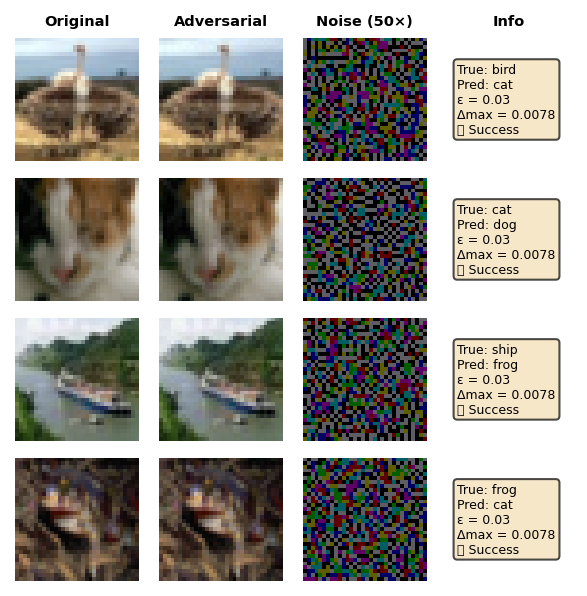

In [77]:
print("\n" + "="*60)
print("Visualizing 4 Successful FGSM Attacks")
print("="*60)

# Filter successful attacks
successful_attacks = [r for r in all_results if r['success']]

# Take up to 4 samples
num_show = min(4, len(successful_attacks))
selected = successful_attacks[:num_show]

# Twice the previous size
fig, axes = plt.subplots(num_show, 4, figsize=(4.0, 1.0 * num_show), dpi=150)

if num_show == 1:
    axes = axes.reshape(1, -1)

# Column headers
col_titles = ['Original', 'Adversarial', 'Noise (50×)', 'Info']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=7, fontweight='bold')

for i, result in enumerate(selected):
    # Denormalize images
    orig_img = denormalize(result['original_image'].clone(), mean, std)
    adv_img = denormalize(result['perturbed_image'].clone(), mean, std)
    
    # Compute the perturbation in pixel space
    noise_pixel = (adv_img - orig_img)
    
    # Amplify noise for visibility (50x)
    noise_amplified = noise_pixel * 50
    noise_amplified = torch.clamp(noise_amplified, 0, 1)
    
    # Column 1: Original Image
    axes[i, 0].imshow(orig_img.permute(1, 2, 0).detach().numpy())
    axes[i, 0].axis('off')
    
    # Column 2: Adversarial Image
    axes[i, 1].imshow(adv_img.permute(1, 2, 0).detach().numpy())
    axes[i, 1].axis('off')
    
    # Column 3: Amplified Noise
    axes[i, 2].imshow(noise_amplified.permute(1, 2, 0).detach().numpy())
    axes[i, 2].axis('off')
    
    # Column 4: Information
    info_text = (
        f"True: {CIFAR10_CLASSES[result['true_label']]}\n"
        f"Pred: {CIFAR10_CLASSES[result['predicted_label']]}\n"
        f"ε = {EPSILON}\n"
        f"Δmax = {noise_pixel.abs().max().item():.4f}\n"
        f"✅ Success"
    )
    axes[i, 3].text(0.1, 0.5, info_text, fontsize=6, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7, pad=0.3))
    axes[i, 3].axis('off')

plt.tight_layout(pad=0.8)
plt.show()

#### Detailed Report for Each of the 4 Samples

In [78]:
print("\n" + "="*60)
print("Detailed Report for 4 Successful Attack Samples")
print("="*60)

for i, result in enumerate(selected):
    print(f"\n--- Sample {i+1} ---")
    print(f"  True Label:            {CIFAR10_CLASSES[result['true_label']]} (class {result['true_label']})")
    print(f"  Predicted Label:       {CIFAR10_CLASSES[result['predicted_label']]} (class {result['predicted_label']})")
    print(f"  Epsilon (ε):           {EPSILON}")
    
    # Calculate perturbation statistics
    noise_tensor = result['noise']
    noise_l2 = torch.norm(noise_tensor, p=2).item()
    noise_linf = torch.norm(noise_tensor, p=float('inf')).item()
    noise_mean = noise_tensor.abs().mean().item()
    
    print(f"  Noise L2 Norm:         {noise_l2:.6f}")
    print(f"  Noise L∞ Norm:         {noise_linf:.6f}")
    print(f"  Noise Mean Absolute:   {noise_mean:.6f}")
    print(f"  Attack Status:         ✅ Successfully fooled the model")


Detailed Report for 4 Successful Attack Samples

--- Sample 1 ---
  True Label:            bird (class 2)
  Predicted Label:       cat (class 3)
  Epsilon (ε):           0.03
  Noise L2 Norm:         1.662769
  Noise L∞ Norm:         0.030000
  Noise Mean Absolute:   0.030000
  Attack Status:         ✅ Successfully fooled the model

--- Sample 2 ---
  True Label:            cat (class 3)
  Predicted Label:       dog (class 5)
  Epsilon (ε):           0.03
  Noise L2 Norm:         1.662769
  Noise L∞ Norm:         0.030000
  Noise Mean Absolute:   0.030000
  Attack Status:         ✅ Successfully fooled the model

--- Sample 3 ---
  True Label:            ship (class 8)
  Predicted Label:       frog (class 6)
  Epsilon (ε):           0.03
  Noise L2 Norm:         1.662769
  Noise L∞ Norm:         0.030000
  Noise Mean Absolute:   0.030000
  Attack Status:         ✅ Successfully fooled the model

--- Sample 4 ---
  True Label:            frog (class 6)
  Predicted Label:       cat (class

## PGD Attack

#### PGD Attack Implementation

In [79]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, mean, std):
    """
    Projected Gradient Descent (PGD) Attack - L∞ norm
    
    Args:
        model: Trained model
        images: Batch of input images (normalized)
        labels: True labels
        epsilon: Maximum perturbation magnitude (L∞ bound)
        alpha: Step size per iteration
        num_steps: Number of PGD iterations
        mean: Mean tensor for normalization
        std: Standard deviation tensor for normalization
    
    Returns:
        perturbed_images: Adversarial images
        noise: The added perturbation
    """
    # Store original images
    original_images = images.clone().detach()
    
    # Initialize perturbed images with a small random perturbation
    # (random start within epsilon ball)
    perturbed_images = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    
    # Clamp to valid pixel range in normalized space
    lower_bound = -mean / std
    upper_bound = (1 - mean) / std
    
    for c in range(3):
        perturbed_images[:, c, :, :] = torch.clamp(
            perturbed_images[:, c, :, :],
            lower_bound[c].item(),
            upper_bound[c].item()
        )
    
    for step in range(num_steps):
        # Enable gradient tracking
        perturbed_images.requires_grad = True
        
        # Forward pass
        outputs = model(perturbed_images)
        loss = torch.nn.CrossEntropyLoss()(outputs, labels)
        
        # Backward pass
        model.zero_grad()
        loss.backward()
        
        # Take a step in the gradient direction
        with torch.no_grad():
            grad_sign = perturbed_images.grad.sign()
            
            # Update: x = x + alpha * sign(grad)
            perturbed_images = perturbed_images + alpha * grad_sign
            
            # Project back to epsilon ball (L∞ norm)
            delta = perturbed_images - original_images
            delta = torch.clamp(delta, -epsilon, epsilon)
            perturbed_images = original_images + delta
            
            # Clamp to valid pixel range
            for c in range(3):
                perturbed_images[:, c, :, :] = torch.clamp(
                    perturbed_images[:, c, :, :],
                    lower_bound[c].item(),
                    upper_bound[c].item()
                )
    
    # Compute final noise
    noise = perturbed_images.detach() - original_images
    
    return perturbed_images.detach(), noise


def denormalize(images, mean, std):
    """Convert normalized images back to [0, 1] range for visualization."""
    images = images * std + mean
    return torch.clamp(images, 0, 1)


#### Run PGD Attack on All Samples

In [80]:
print("\n" + "="*60)
print("PGD Attack (L∞, ε=0.03, α=0.005, steps=20)")
print("="*60)

PGD_EPSILON = 0.03      # Maximum L∞ perturbation
PGD_ALPHA = 0.005       # Step size per iteration
PGD_STEPS = 20          # Number of iterations

# Store all results
all_pgd_results = []

model.eval()

for images, labels in tqdm(dataloader, desc="Running PGD attack"):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    
    # Generate adversarial examples with PGD
    perturbed_images, noise = pgd_attack(
        model, images, labels, 
        PGD_EPSILON, PGD_ALPHA, PGD_STEPS, 
        mean.to(DEVICE), std.to(DEVICE)
    )
    
    # Get predictions on adversarial examples
    with torch.no_grad():
        outputs_adv = model(perturbed_images)
        _, predicted_adv = torch.max(outputs_adv, 1)
    
    # Store results for this batch
    for i in range(len(images)):
        success = predicted_adv[i].item() != labels[i].item()
        all_pgd_results.append({
            'original_image': images[i].cpu(),
            'perturbed_image': perturbed_images[i].cpu(),
            'noise': noise[i].cpu(),
            'true_label': labels[i].item(),
            'predicted_label': predicted_adv[i].item(),
            'success': success
        })



PGD Attack (L∞, ε=0.03, α=0.005, steps=20)


Running PGD attack: 100%|██████████| 7/7 [00:05<00:00,  1.23it/s]


#### PGD Attack Report

In [81]:
num_success = sum(1 for r in all_pgd_results if r['success'])
success_rate = 100 * num_success / len(all_pgd_results)

print(f"\nTotal samples: {len(all_pgd_results)}")
print(f"Successful attacks (misclassified): {num_success}")
print(f"Attack success rate: {success_rate:.2f}%")



Total samples: 25
Successful attacks (misclassified): 24
Attack success rate: 96.00%


#### Visualize 4 Successful PGD Attack Samples


Visualizing 4 Successful PGD Attacks


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_4280\1857439087.py:63: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.8)


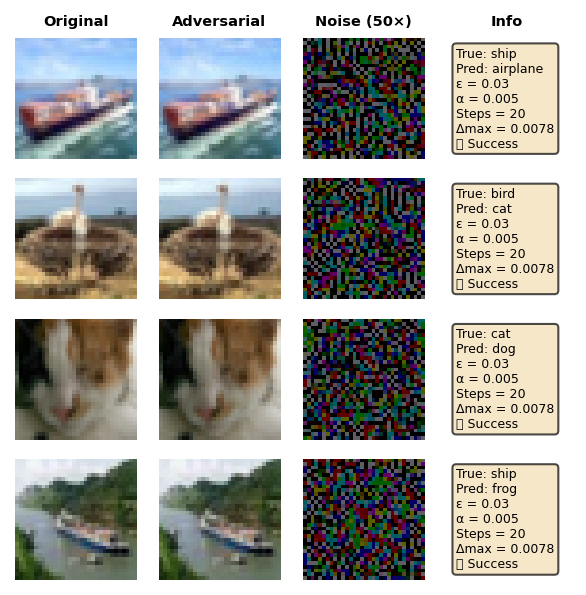

In [82]:
print("\n" + "="*60)
print("Visualizing 4 Successful PGD Attacks")
print("="*60)

# Filter successful attacks
successful_attacks = [r for r in all_pgd_results if r['success']]

if len(successful_attacks) < 4:
    print(f"⚠️  Only {len(successful_attacks)} successful attacks found. Showing all.")

# Take up to 4 samples
num_show = min(4, len(successful_attacks))
selected = successful_attacks[:num_show]

fig, axes = plt.subplots(num_show, 4, figsize=(4.0, 1.0 * num_show), dpi=150)

if num_show == 1:
    axes = axes.reshape(1, -1)

# Column headers
col_titles = ['Original', 'Adversarial', 'Noise (50×)', 'Info']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=7, fontweight='bold')

for i, result in enumerate(selected):
    # Denormalize images
    orig_img = denormalize(result['original_image'].clone(), mean, std)
    adv_img = denormalize(result['perturbed_image'].clone(), mean, std)
    
    # Compute the perturbation in pixel space
    noise_pixel = (adv_img - orig_img)
    
    # Amplify noise for visibility (50x)
    noise_amplified = noise_pixel * 50
    noise_amplified = torch.clamp(noise_amplified, 0, 1)
    
    # Column 1: Original Image
    axes[i, 0].imshow(orig_img.permute(1, 2, 0).detach().numpy())
    axes[i, 0].axis('off')
    
    # Column 2: Adversarial Image
    axes[i, 1].imshow(adv_img.permute(1, 2, 0).detach().numpy())
    axes[i, 1].axis('off')
    
    # Column 3: Amplified Noise
    axes[i, 2].imshow(noise_amplified.permute(1, 2, 0).detach().numpy())
    axes[i, 2].axis('off')
    
    # Column 4: Information
    info_text = (
        f"True: {CIFAR10_CLASSES[result['true_label']]}\n"
        f"Pred: {CIFAR10_CLASSES[result['predicted_label']]}\n"
        f"ε = {PGD_EPSILON}\n"
        f"α = {PGD_ALPHA}\n"
        f"Steps = {PGD_STEPS}\n"
        f"Δmax = {noise_pixel.abs().max().item():.4f}\n"
        f"✅ Success"
    )
    axes[i, 3].text(0.1, 0.5, info_text, fontsize=6, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7, pad=0.3))
    axes[i, 3].axis('off')

plt.tight_layout(pad=0.8)
plt.show()


#### Detailed Report for Each of the 4 Samples


In [83]:
print("\n" + "="*60)
print("Detailed Report for 4 Successful PGD Attack Samples")
print("="*60)

for i, result in enumerate(selected):
    noise_tensor = result['noise']
    noise_l2 = torch.norm(noise_tensor, p=2).item()
    noise_linf = torch.norm(noise_tensor, p=float('inf')).item()
    
    print(f"\n--- Sample {i+1} ---")
    print(f"  True Label:            {CIFAR10_CLASSES[result['true_label']]} (class {result['true_label']})")
    print(f"  Predicted Label:       {CIFAR10_CLASSES[result['predicted_label']]} (class {result['predicted_label']})")
    print(f"  Epsilon (ε):           {PGD_EPSILON} (L∞ bound)")
    print(f"  Step Size (α):         {PGD_ALPHA}")
    print(f"  Number of Steps:       {PGD_STEPS}")
    print(f"  Noise L∞ Norm:         {noise_linf:.6f} (≤ {PGD_EPSILON})")
    print(f"  Noise L2 Norm:         {noise_l2:.6f}")
    print(f"  Attack Status:         ✅ Successfully fooled the model")


Detailed Report for 4 Successful PGD Attack Samples

--- Sample 1 ---
  True Label:            ship (class 8)
  Predicted Label:       airplane (class 0)
  Epsilon (ε):           0.03 (L∞ bound)
  Step Size (α):         0.005
  Number of Steps:       20
  Noise L∞ Norm:         0.030000 (≤ 0.03)
  Noise L2 Norm:         1.474541
  Attack Status:         ✅ Successfully fooled the model

--- Sample 2 ---
  True Label:            bird (class 2)
  Predicted Label:       cat (class 3)
  Epsilon (ε):           0.03 (L∞ bound)
  Step Size (α):         0.005
  Number of Steps:       20
  Noise L∞ Norm:         0.030000 (≤ 0.03)
  Noise L2 Norm:         1.463706
  Attack Status:         ✅ Successfully fooled the model

--- Sample 3 ---
  True Label:            cat (class 3)
  Predicted Label:       dog (class 5)
  Epsilon (ε):           0.03 (L∞ bound)
  Step Size (α):         0.005
  Number of Steps:       20
  Noise L∞ Norm:         0.030000 (≤ 0.03)
  Noise L2 Norm:         1.391681
  Attac